# Confusion Matrix in 60 Seconds
### The Foundation of Classification Metrics

**Confusion Matrix = 2×2 table showing predictions vs reality**
- True Positives (TP): Correctly predicted positive
- True Negatives (TN): Correctly predicted negative
- False Positives (FP): Incorrectly predicted positive (Type I error)
- False Negatives (FN): Incorrectly predicted negative (Type II error)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)

## 1. The Basic Structure
**Understanding the 2×2 grid**

In [2]:
# Create a simple example
y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0])  # Actual labels
y_pred = np.array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0])  # Predicted labels

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

print("Example Predictions:")
print(f"True labels:      {y_true}")
print(f"Predicted labels: {y_pred}")
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

Example Predictions:
True labels:      [1 0 1 1 0 1 0 0 1 0]
Predicted labels: [1 0 1 0 0 1 1 0 1 0]

Confusion Matrix:
[[4 1]
 [1 4]]

True Negatives (TN):  4
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP):  4


## 2. Visual Explanation
**Color-coded confusion matrix**

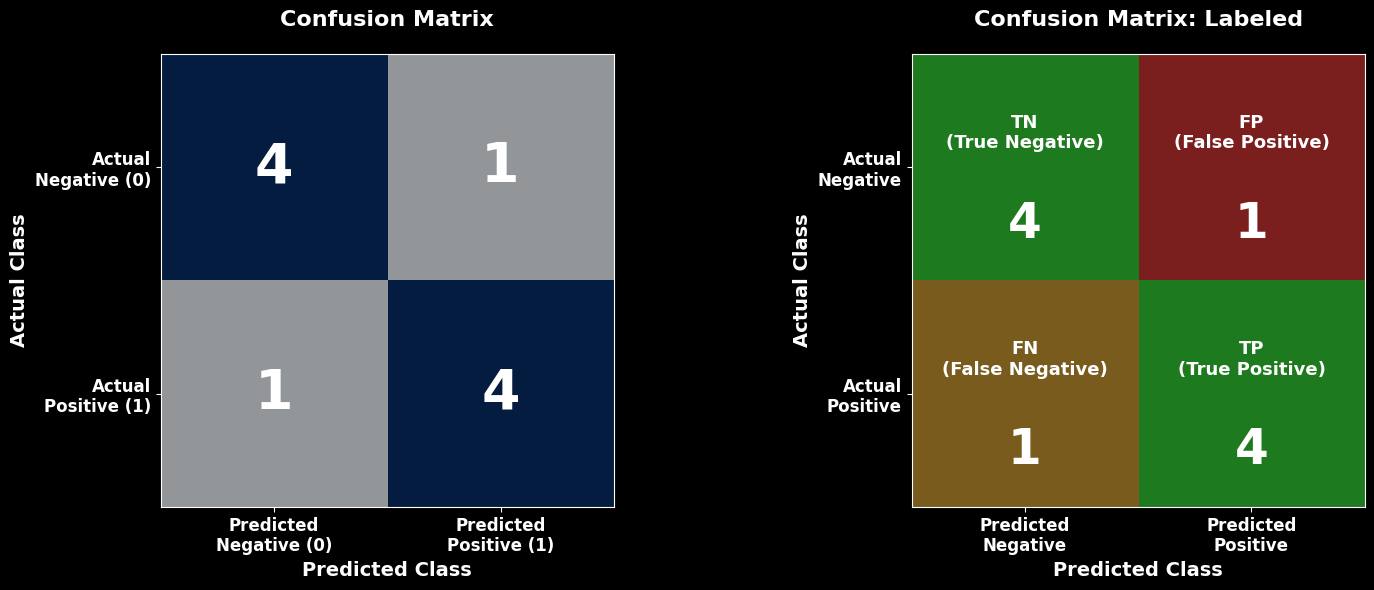


Color Guide:
🟢 GREEN (TN, TP): CORRECT predictions
🔴 RED (FP): Type I error - False alarm
🟠 ORANGE (FN): Type II error - Missed detection


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Basic heatmap
ax1 = axes[0]
im = ax1.imshow(cm, cmap='Blues', alpha=0.6)

# Add text annotations
for i in range(2):
    for j in range(2):
        value = cm[i, j]
        text_color = 'white' if value > cm.max()/2 else 'white'
        ax1.text(j, i, str(value), ha='center', va='center',
                fontsize=40, fontweight='bold', color=text_color)

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Predicted\nNegative (0)', 'Predicted\nPositive (1)'], 
                    fontsize=12, fontweight='bold')
ax1.set_yticklabels(['Actual\nNegative (0)', 'Actual\nPositive (1)'], 
                    fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Class', fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual Class', fontsize=14, fontweight='bold')
ax1.set_title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)

# Plot 2: Labeled with names
ax2 = axes[1]

# Create custom colormap
colors = np.array([[0.2, 0.8, 0.2, 0.6],   # TN - Green
                   [0.8, 0.2, 0.2, 0.6],   # FP - Red
                   [0.8, 0.6, 0.2, 0.6],   # FN - Orange
                   [0.2, 0.8, 0.2, 0.6]])  # TP - Green
colors = colors.reshape(2, 2, 4)

ax2.imshow(colors)

# Add labels with values
labels = [['TN\n(True Negative)', 'FP\n(False Positive)'],
          ['FN\n(False Negative)', 'TP\n(True Positive)']]
values = [[tn, fp], [fn, tp]]

for i in range(2):
    for j in range(2):
        # Label
        ax2.text(j, i-0.15, labels[i][j], ha='center', va='center',
                fontsize=13, fontweight='bold', color='white')
        # Value
        ax2.text(j, i+0.25, f'{values[i][j]}', ha='center', va='center',
                fontsize=35, fontweight='bold', color='white')

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Predicted\nNegative', 'Predicted\nPositive'], 
                    fontsize=12, fontweight='bold')
ax2.set_yticklabels(['Actual\nNegative', 'Actual\nPositive'], 
                    fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Class', fontsize=14, fontweight='bold')
ax2.set_ylabel('Actual Class', fontsize=14, fontweight='bold')
ax2.set_title('Confusion Matrix: Labeled', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nColor Guide:")
print("="*60)
print("🟢 GREEN (TN, TP): CORRECT predictions")
print("🔴 RED (FP): Type I error - False alarm")
print("🟠 ORANGE (FN): Type II error - Missed detection")
print("="*60)

## 3. Real Example: Disease Detection
**Medical diagnosis scenario**

In [4]:
# Generate synthetic data
X, y = make_classification(n_samples=200, n_features=10, n_informative=8,
                          n_redundant=2, random_state=42, flip_y=0.1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm_real = confusion_matrix(y_test, y_pred)
tn_r, fp_r, fn_r, tp_r = cm_real.ravel()

# Metrics
accuracy = (tp_r + tn_r) / (tp_r + tn_r + fp_r + fn_r)
precision = tp_r / (tp_r + fp_r) if (tp_r + fp_r) > 0 else 0
recall = tp_r / (tp_r + fn_r) if (tp_r + fn_r) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Disease Detection Model (200 patients):")
print("="*60)
print(f"Total Patients: {len(y_test)}")
print(f"Actually Sick: {np.sum(y_test)}")
print(f"Actually Healthy: {len(y_test) - np.sum(y_test)}")
print("\nConfusion Matrix:")
print(cm_real)
print("\nBreakdown:")
print(f"  True Negatives (TN):  {tn_r} - Correctly identified healthy ✓")
print(f"  False Positives (FP): {fp_r} - Healthy but diagnosed sick ✗")
print(f"  False Negatives (FN): {fn_r} - Sick but diagnosed healthy ✗✗ DANGEROUS!")
print(f"  True Positives (TP):  {tp_r} - Correctly identified sick ✓")
print("\nMetrics:")
print(f"  Accuracy:  {accuracy:.3f} - Overall correctness")
print(f"  Precision: {precision:.3f} - Of predicted sick, how many actually sick?")
print(f"  Recall:    {recall:.3f} - Of actually sick, how many detected?")
print(f"  F1-Score:  {f1:.3f} - Harmonic mean of precision & recall")
print("="*60)

Disease Detection Model (200 patients):
Total Patients: 60
Actually Sick: 37
Actually Healthy: 23

Confusion Matrix:
[[22  1]
 [13 24]]

Breakdown:
  True Negatives (TN):  22 - Correctly identified healthy ✓
  False Positives (FP): 1 - Healthy but diagnosed sick ✗
  False Negatives (FN): 13 - Sick but diagnosed healthy ✗✗ DANGEROUS!
  True Positives (TP):  24 - Correctly identified sick ✓

Metrics:
  Accuracy:  0.767 - Overall correctness
  Precision: 0.960 - Of predicted sick, how many actually sick?
  Recall:    0.649 - Of actually sick, how many detected?
  F1-Score:  0.774 - Harmonic mean of precision & recall


## 4. Visualize with Annotations

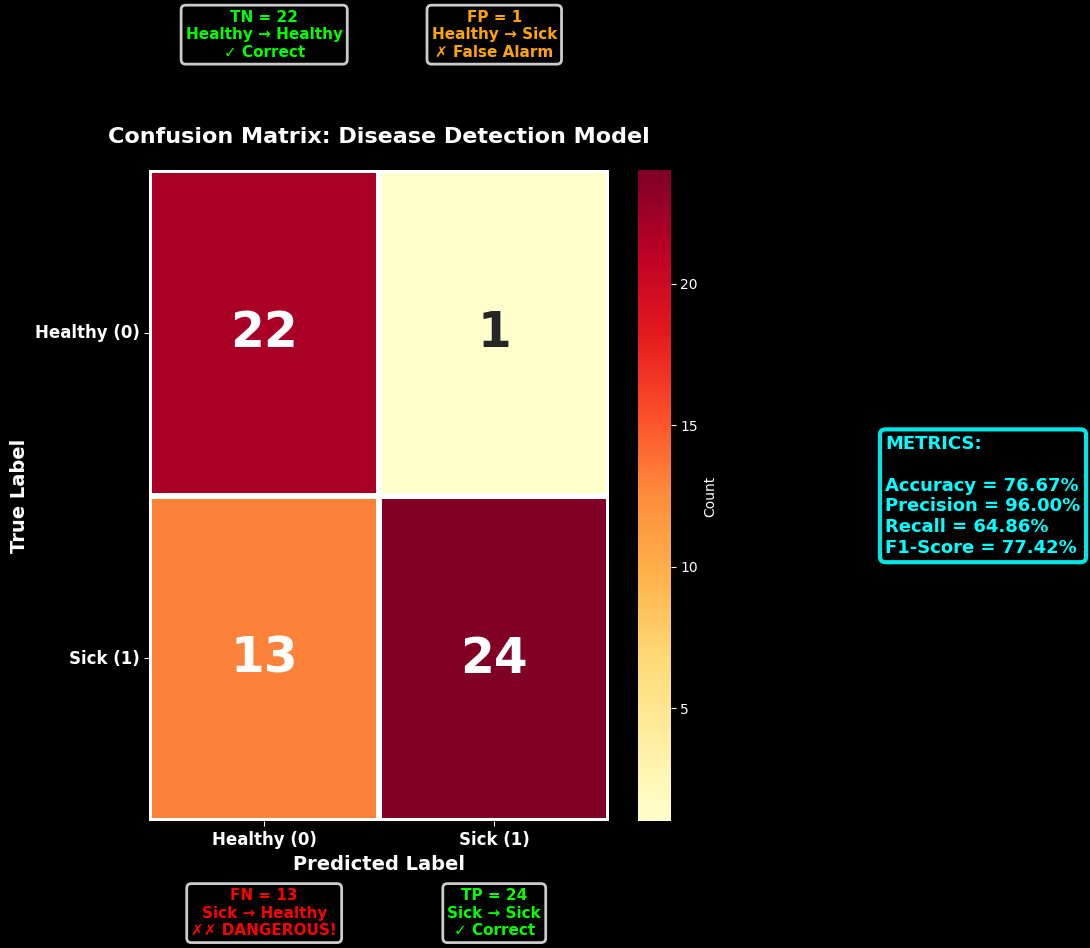

In [5]:
fig, ax = plt.subplots(figsize=(12, 10))

# Create heatmap
sns.heatmap(cm_real, annot=True, fmt='d', cmap='YlOrRd', 
           cbar_kws={'label': 'Count'}, linewidths=3, linecolor='white',
           annot_kws={'size': 35, 'weight': 'bold'})

ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_title('Confusion Matrix: Disease Detection Model', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(['Healthy (0)', 'Sick (1)'], fontsize=12, fontweight='bold')
ax.set_yticklabels(['Healthy (0)', 'Sick (1)'], fontsize=12, fontweight='bold', rotation=0)

# Add interpretation boxes
bbox_props = dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='white', linewidth=2)

# TN
ax.text(0.5, -0.35, f'TN = {tn_r}\nHealthy → Healthy\n✓ Correct', 
       transform=ax.transData, ha='center', fontsize=11, color='lime',
       fontweight='bold', bbox=bbox_props)

# FP
ax.text(1.5, -0.35, f'FP = {fp_r}\nHealthy → Sick\n✗ False Alarm', 
       transform=ax.transData, ha='center', fontsize=11, color='orange',
       fontweight='bold', bbox=bbox_props)

# FN
ax.text(0.5, 2.35, f'FN = {fn_r}\nSick → Healthy\n✗✗ DANGEROUS!', 
       transform=ax.transData, ha='center', fontsize=11, color='red',
       fontweight='bold', bbox=bbox_props)

# TP
ax.text(1.5, 2.35, f'TP = {tp_r}\nSick → Sick\n✓ Correct', 
       transform=ax.transData, ha='center', fontsize=11, color='lime',
       fontweight='bold', bbox=bbox_props)

# Add metrics on the side
metrics_text = f"METRICS:\n\n" \
              f"Accuracy = {accuracy:.2%}\n" \
              f"Precision = {precision:.2%}\n" \
              f"Recall = {recall:.2%}\n" \
              f"F1-Score = {f1:.2%}"

ax.text(3.2, 1, metrics_text, transform=ax.transData, 
       fontsize=13, fontweight='bold', color='cyan',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.9, 
                edgecolor='cyan', linewidth=3),
       verticalalignment='center')

plt.tight_layout()
plt.show()

## 5. Deriving Metrics from Confusion Matrix

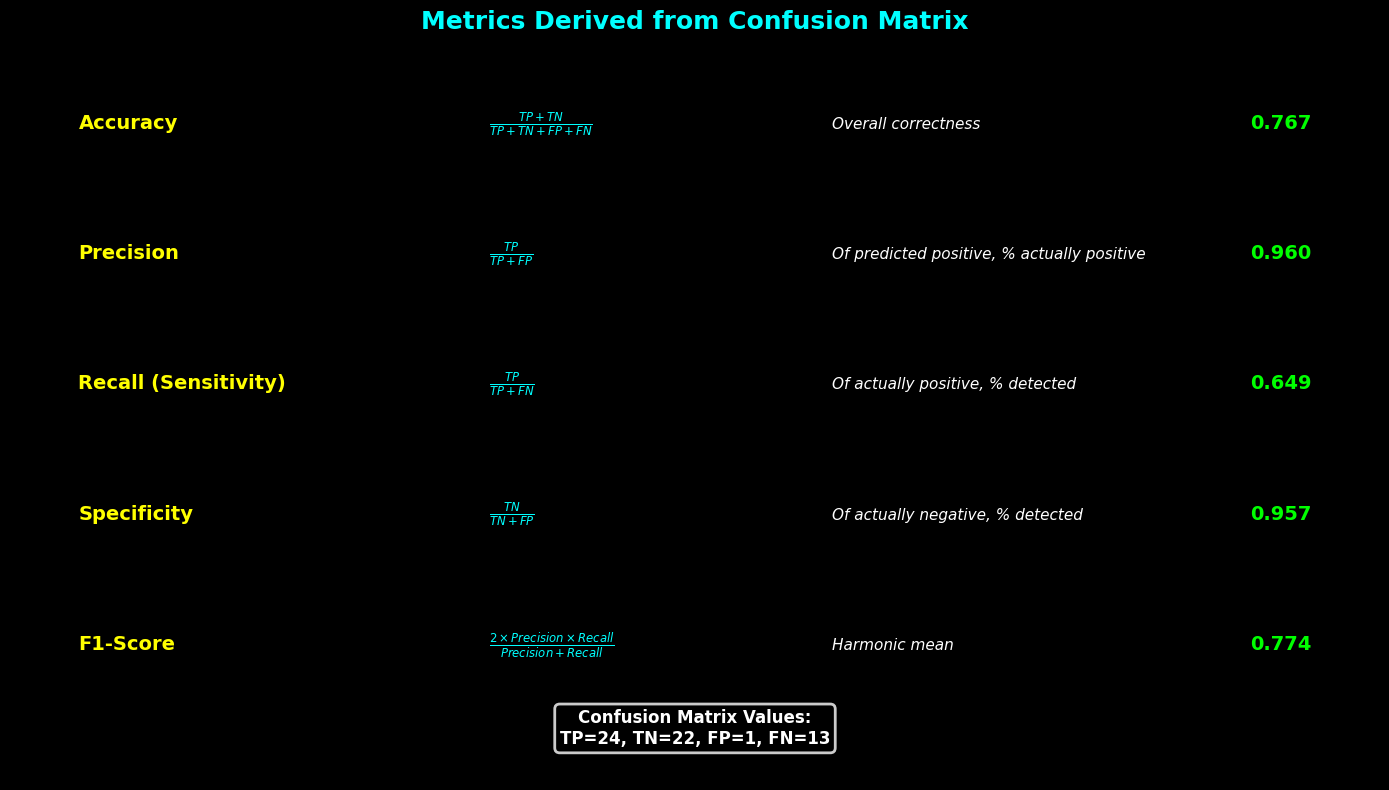

In [6]:
# Visual guide to metrics
fig, ax = plt.subplots(figsize=(14, 8))

# Create visual representation
formulas = [
    ('Accuracy', r'$\frac{TP + TN}{TP + TN + FP + FN}$', 'Overall correctness', f'{accuracy:.3f}'),
    ('Precision', r'$\frac{TP}{TP + FP}$', 'Of predicted positive, % actually positive', f'{precision:.3f}'),
    ('Recall (Sensitivity)', r'$\frac{TP}{TP + FN}$', 'Of actually positive, % detected', f'{recall:.3f}'),
    ('Specificity', r'$\frac{TN}{TN + FP}$', 'Of actually negative, % detected', f'{tn_r/(tn_r+fp_r):.3f}'),
    ('F1-Score', r'$\frac{2 \times Precision \times Recall}{Precision + Recall}$', 'Harmonic mean', f'{f1:.3f}')
]

y_pos = 0.9
for name, formula, description, value in formulas:
    # Name
    ax.text(0.05, y_pos, name, fontsize=14, fontweight='bold', 
           color='yellow', transform=ax.transAxes)
    # Formula
    ax.text(0.35, y_pos, formula, fontsize=12, color='cyan', 
           transform=ax.transAxes)
    # Description
    ax.text(0.60, y_pos, description, fontsize=11, color='white', 
           transform=ax.transAxes, style='italic')
    # Value
    ax.text(0.95, y_pos, value, fontsize=14, fontweight='bold', 
           color='lime', transform=ax.transAxes, ha='right')
    
    y_pos -= 0.18

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Metrics Derived from Confusion Matrix', 
            fontsize=18, fontweight='bold', pad=20, color='cyan')

# Add confusion matrix values as reference
cm_text = f"Confusion Matrix Values:\nTP={tp_r}, TN={tn_r}, FP={fp_r}, FN={fn_r}"
ax.text(0.5, 0.05, cm_text, transform=ax.transAxes, 
       fontsize=12, fontweight='bold', ha='center', color='white',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                edgecolor='white', linewidth=2))

plt.tight_layout()
plt.show()

## 6. Key Takeaways

### What is a Confusion Matrix?
**2×2 table comparing predictions vs actual labels**

### The Four Quadrants:

**True Positive (TP):**
- Predicted: Positive
- Actual: Positive
- ✓ Correct!

**True Negative (TN):**
- Predicted: Negative
- Actual: Negative
- ✓ Correct!

**False Positive (FP) - Type I Error:**
- Predicted: Positive
- Actual: Negative
- ✗ False alarm!
- Example: Healthy person diagnosed as sick

**False Negative (FN) - Type II Error:**
- Predicted: Negative
- Actual: Positive
- ✗✗ Missed detection!
- Example: Sick person diagnosed as healthy (DANGEROUS!)

### Key Metrics:

**Accuracy = (TP + TN) / Total**
- Overall correctness
- Can be misleading with imbalanced data!

**Precision = TP / (TP + FP)**
- Of predicted positives, how many are actually positive?
- Important when FP is costly

**Recall = TP / (TP + FN)**
- Of actual positives, how many did we detect?
- Important when FN is costly

**F1-Score = 2 × (Precision × Recall) / (Precision + Recall)**
- Harmonic mean of precision and recall
- Balanced metric

### When to Use:
- ✓ Binary classification evaluation
- ✓ Understanding model errors
- ✓ Comparing different models
- ✓ Identifying bias in predictions

### Diagonal = Good!
- Main diagonal (TN, TP) = Correct predictions
- Off-diagonal (FP, FN) = Errors
- Goal: Maximize diagonal, minimize off-diagonal

### Trade-offs:
- **High Precision**: Few false alarms, but might miss some positives
- **High Recall**: Catch all positives, but more false alarms
- **Balance**: Use F1-score

### Remember:
**Confusion Matrix is the FOUNDATION of all classification metrics!** 🎯

Every metric (precision, recall, F1, accuracy) comes from these 4 numbers: TP, TN, FP, FN